## Executive Summary

This notebook explores the modeling of daily stock excess growth rates using Hidden Markov Models (HMMs). The analysis proceeds in three main stages:
1.  A standard HMM is built from historical in-sample data.
2.  This model is then tested against well-known "stylized facts" of financial returns, revealing its strengths (capturing return distributions) and weaknesses (failing to capture volatility clustering).
3.  To address these weaknesses, a modified HMM that incorporates price jumps is introduced and analyzed, demonstrating its improved ability to replicate the observed market dynamics.

 # Build a Hidden Markov Model of Daily Stock Excess Growth Rate
We are constructing an Observable Markov Model (OMM) of the excess growth rate of a ticker `XYZ` where we define the excess growth as:
$$
\begin{equation*}
R_{ij} \equiv \left(\frac{1}{\Delta{t}}\right)\cdot\ln\left(\frac{S_{i,j}}{S_{i,j-1}}\right) - \bar{r}_{f}
\end{equation*}
$$
where $R_{ij}$ denotes the excess growth rate of equity $i$ at time $j$, $\Delta{t}$ denotes the time-step between $j-1\rightarrow{j}$ (units: years), $S_{i,\star}$ denotes the share price of equity $i$ at time $\star$, and $\bar{r}_{f}$ denotes the annualized risk free rate. In this work, we build a model of daily return.

## Model
Describe the day-to-day variation of the excess growth using a fully observable Markov model $\mathcal{M}$ represented by the tuple $\mathcal{M} = (\mathcal{S},\mathcal{O},\mathbf{P},\mathbf{E})$; $\mathcal{S}$ is the set of hidden states, $\mathcal{O}$ is the set of observable states, $\mathbf{T}$ is the transition matrix, i.e., $t_{ij}\in\mathbf{T}$ is the probability of moving from hidden state $i$ to hidden state $j$ in the next time step, and $\mathbf{E}$ is the emission matrix. Because we are fully observable, the emission matrix $\mathbf{E} = \mathbf{I}$, where $\mathbf{I}$ is the identity matrix.

## Objectives
- **Task 1:** Characterize the continuous distribution of returns using MLE and MCMC, then discretize this distribution to build a Hidden Markov Model (HMM).
- **Task 2:** Simulate the standard HMM and analyze its ability to reproduce key stylized facts of financial returns, particularly volatility clustering.
- **Task 3:** Introduce and analyze an HMM with jumps to see if it improves upon the standard model's weaknesses.
- **Task 4:** Save the final model artifacts for future use.

## Setup
We set up the computational environment by including the `Include.jl` file. The `Include.jl` file loads external packages, various functions that we will use in the exercise, and custom types to model the components of our lab problem.
* For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl).

In [1]:
include("Include.jl");

## Setting Up Constants

In [2]:
risk_free_rate = 0.0421; # 17-Jun-2024 10-year treasury
Δt = (1/252); # time step 1 x trading in units of years
number_of_paths = 1000; # number of potential futures should we look at
ticker = "NVDA"; # This is the ticker we want to explore

## Prerequisites: Load and clean the historical dataset
We gathered a daily open-high-low-close `dataset` for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `02-07-2025`, along with data for a few exchange-traded funds and volatility products during that time. In this block of code, we:
* Load and clean the historical data; store the cleaned data in the `dataset` variable. We then calculate the expected excess return $\mathbb{E}(R_{i})$ for each `ticker` in the `dataset.` Finally, you'll select a firm by changing the value in the `ticker` variable. We store the computed excess return for the `ticker` in the `Rᵢ` variable.

### Load the training data

The dataset for this analysis consists of daily open-high-low-close (OHLC) data for firms in the S&P 500, spanning from **January 3, 2014, to February 7, 2025**. This data was cleaned and split into training and testing sets in a separate preprocessing step.

We begin by loading the pre-cleaned **training dataset** below.

In [3]:
train_dataset = MyPortfolioDataSet() |> x->x["dataset"]

Dict{String, DataFrame} with 515 entries:
  "DD"   => 2329×8 DataFrame…
  "EMR"  => 2767×8 DataFrame…
  "CTAS" => 2767×8 DataFrame…
  "HSIC" => 2767×8 DataFrame…
  "KIM"  => 2767×8 DataFrame…
  "PLD"  => 2767×8 DataFrame…
  "IEX"  => 2767×8 DataFrame…
  "TPR"  => 1803×8 DataFrame…
  "BAC"  => 2767×8 DataFrame…
  "CBOE" => 2767×8 DataFrame…
  "EXR"  => 2767×8 DataFrame…
  "NCLH" => 2767×8 DataFrame…
  "CVS"  => 2767×8 DataFrame…
  "DRI"  => 2767×8 DataFrame…
  "DTE"  => 2767×8 DataFrame…
  "ZION" => 2767×8 DataFrame…
  "AVY"  => 2767×8 DataFrame…
  "EW"   => 2767×8 DataFrame…
  "EA"   => 2767×8 DataFrame…
  "NWSA" => 2767×8 DataFrame…
  "BBWI" => 859×8 DataFrame…
  "CAG"  => 2767×8 DataFrame…
  "GPC"  => 2767×8 DataFrame…
  "FCX"  => 2767×8 DataFrame…
  "GILD" => 2767×8 DataFrame…
  ⋮      => ⋮

In [4]:
train_dataset["AAPL"]

Row,volume,volume_weighted_average_price,open,close,high,low,timestamp,number_of_transactions
,Float64,Float64,Float64,Float64,Float64,Float64,DateTime,Int64
1,3.93215e8,19.4749,19.745,19.3207,19.775,19.3011,2014-01-03T05:00:00,148584
2,4.13437e8,19.3213,19.1946,19.4261,19.5286,19.0571,2014-01-06T05:00:00,131664
3,3.17731e8,19.3329,19.44,19.2871,19.4986,19.2116,2014-01-07T05:00:00,107327
4,2.58747e8,19.4038,19.2432,19.4093,19.4843,19.2389,2014-01-08T05:00:00,86874
5,2.79621e8,19.2943,19.5286,19.1614,19.5307,19.1196,2014-01-09T05:00:00,93562
6,3.05283e8,19.0659,19.2796,19.0336,19.3143,18.9682,2014-01-10T05:00:00,113063
7,3.79443e8,19.1801,18.9254,19.1332,19.375,18.9243,2014-01-13T05:00:00,130227
8,3.34937e8,19.4033,19.2221,19.5139,19.5261,19.2021,2014-01-14T05:00:00,114856
9,3.9389e8,19.9105,19.7686,19.9057,20.0071,19.7021,2014-01-15T05:00:00,136942


In [5]:
maximum_number_trading_days = nrow(train_dataset["AAPL"])

2767

In [6]:
dataset = Dict{String,DataFrame}();
for (ticker,data) ∈ train_dataset
    if (nrow(data) == maximum_number_trading_days)
        dataset[ticker] = data;
    end
end

Lastly, let's get a sorted list of firms that we have in cleaned up `dataset` and save it in the `list_of_all_tickers::Array{String,1}` array

In [7]:
list_of_all_tickers = keys(dataset) |> collect |> x->sort(x)

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

We compute the expected (annualized) log growth rate by passing the `dataset` and the entire list of firms we have in the dataset (held in the $N\times{1}$ `list_of_all_tickers` array) to the [log_growth_matrix(...) method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix).
* The result is stored in the `all_firms_return_matrix::Array{Float64,2}` variable, a $T-1\times{N}$ array of log return values. Each row of `all_firms_return_matrix` corresponds to a time value, while each column corresponds to a firm:

In [8]:
all_firms_excess_return_matrix = log_growth_matrix(dataset, list_of_all_tickers,
    Δt = Δt, risk_free_rate = risk_free_rate)

2766×424 Matrix{Float64}:
 -0.919654    6.23895    -2.91307    …  -0.797491   0.203794  -1.04737
  2.77416     1.02939     1.35029        2.09622   -0.84489    0.944368
  3.27095     0.813497   -0.036732       0.067777   1.1489    -2.62354
  0.604325   17.2178      1.65005        0.232616   3.1172    -0.410328
  1.77399     2.53751     3.27714        0.579577  -2.2108     4.36099
  0.57173    -4.00594    -0.83488    …  -0.904839  -1.95187   -3.15834
  2.81861    -0.525851    4.80363        1.7236    -1.81895   -1.1317
  2.00461     0.971404    1.86599        1.63387    4.40774   -0.179919
  1.27079     1.63203     0.0651592     -1.54918   -2.17906    1.39574
  1.17806     6.08747     0.890478      -1.57412    2.83574   -1.47836
 -0.479768    4.82799     0.96564    …  -0.363361   9.46617   -3.05083
  1.32071     3.57107    -2.38986        0.668513   4.48013    0.298431
 -4.78114     1.34375    -3.05834       -2.19455   -6.69117    1.36402
  ⋮                                  ⋱          

Extract the growth rate for your `ticker::String` of interest, and save this in the `Rᵢ::Array{Float64,1}` array. This is the observed _in-sample_ data.

In [9]:
Rᵢ = findfirst(x->x==ticker, list_of_all_tickers) |> i-> all_firms_excess_return_matrix[:,i]

2766-element Vector{Float64}:
 -0.6266399670984476
  0.8405262386945092
  0.16389199696256232
 -0.010233691939436122
  0.25823420862761537
 -1.378088774125505
  0.32241271641711466
  2.0009590819913137
 -0.322149763808254
 -0.43598073791618397
 -0.07579593758943923
  0.3992882778085264
 -1.99925091651247
  ⋮
 -0.5428518800661111
  0.9030508357217608
 -1.0139344267279928
 -3.818285890907456
 -3.0867707822786663
  0.23453278078089898
  1.6089264971962087
  2.689709238274075
  0.7453999191864145
 -2.7609744641560034
 -2.504601843730946
 -0.9624409493684527

In [62]:
number_of_states = 50; # specify a value here, too many states or too little states would impact the model performance. 100 should provide somewhat fair granuality 

In [63]:
in_sample_dataset = Rᵢ[1:(maximum_number_trading_days-1)] # set of excess return

2766-element Vector{Float64}:
 -0.6266399670984476
  0.8405262386945092
  0.16389199696256232
 -0.010233691939436122
  0.25823420862761537
 -1.378088774125505
  0.32241271641711466
  2.0009590819913137
 -0.322149763808254
 -0.43598073791618397
 -0.07579593758943923
  0.3992882778085264
 -1.99925091651247
  ⋮
 -0.5428518800661111
  0.9030508357217608
 -1.0139344267279928
 -3.818285890907456
 -3.0867707822786663
  0.23453278078089898
  1.6089264971962087
  2.689709238274075
  0.7453999191864145
 -2.7609744641560034
 -2.504601843730946
 -0.9624409493684527

## Part 2: Continuous Gaussian HMM (EM Algorithm)

In this section, we transition from the discrete "Quantile-Based" model to a **Continuous Gaussian HMM**. 

Instead of arbitrarily binning returns into fixed discrete states, we assume that each hidden state emits returns according to a **Gaussian Distribution** ($N(\mu_i, \sigma_i)$). We use the **Baum-Welch (Expectation-Maximization)** algorithm to learn the optimal:
1. **Transition Probabilities (T):** How regimes switch.
2. **Emission Parameters ($\mu, \sigma$):** The behavior of each regime.

This approach is more flexible and allows for "fuzzy" states where distributions overlap.

### Checking Convergence
We plot the **Log-Likelihood** history of the EM algorithm. A monotonically increasing curve indicates that the algorithm successfully learned parameters that better explain the observed data with each iteration.

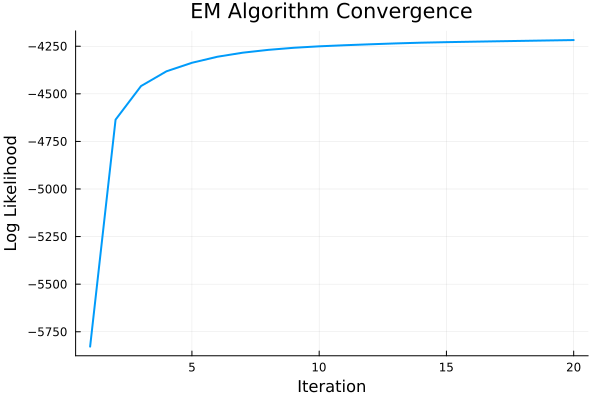

In [64]:
# --- TRAIN CONTINUOUS HMM ---

# 1. Define the number of states (Regimes)
number_of_states = number_of_states; 

# 2. Build and Train the Model
model = build(MyContinuousHiddenMarkovModel, (
    observations = in_sample_dataset, 
    number_of_states = number_of_states
));

# 3. Check Convergence
plot(model.log_likelihood_history, 
    title="EM Algorithm Convergence", 
    xlabel="Iteration", 
    ylabel="Log Likelihood",
    legend=false, lw=2
)

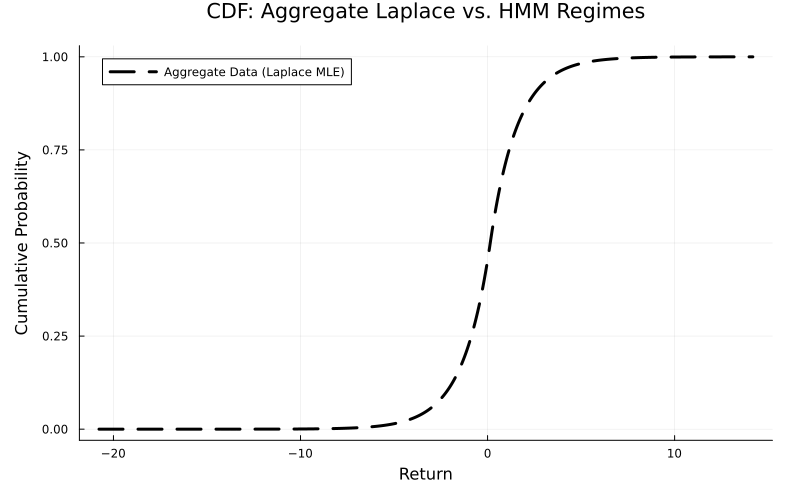

In [145]:

# --- VISUALIZE EMISSIONS VS FITTED LAPLACE ---

# 1. Fit Laplace Distribution to the Aggregate Data
# fitting a Laplace distribution MLE:
L_dist = fit_mle(Laplace, in_sample_dataset)


# 2. Setup
min_ret, max_ret = extrema(in_sample_dataset)
x_grid = range(min_ret, stop=max_ret, length=500)
state_colors = cgrad(:viridis, number_of_states, categorical=true)

# 3. Create the CDF Plot
p_cdf = plot(
    title = "CDF: Aggregate Laplace vs. HMM Regimes",
    xlabel = "Return", 
    ylabel = "Cumulative Probability",
    legend = :topleft,
    size = (800, 500), # Bigger size for standalone plot
    margin = 5Plots.mm
)

# Plot Aggregate
plot!(p_cdf, x_grid, cdf.(L_dist, x_grid), 
    label="Aggregate Data (Laplace MLE)", 
    lw=3, color=:black, linestyle=:dash
)

# Plot States
for s in 1:number_of_states
    d = model.emission[s]
    plot!(p_pdf, x_grid, pdf.(d, x_grid), 
        label="", lw=1, color=state_colors[s], alpha=0.3
    )
end

# # Plot States
# for s in 1:number_of_states
#     d = model.emission[s]
#     plot!(p_cdf, x_grid, cdf.(d, x_grid), 
#         label="", lw=1, color=state_colors[s], alpha=0.3
#     )
# end

display(p_cdf)

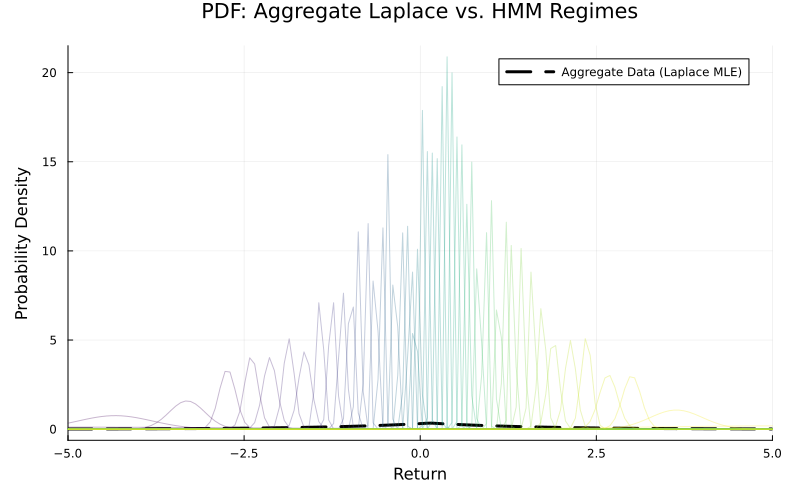

In [144]:
# 3. Create the PDF Plot
p_pdf = plot(
    title = "PDF: Aggregate Laplace vs. HMM Regimes",
    xlabel = "Return", 
    ylabel = "Probability Density",
    legend = :topright,
    xlims = (-5, 5), # Zoom in to see the peaks
    size = (800, 500),
    margin = 5Plots.mm
)

# Plot Aggregate
plot!(p_pdf, x_grid, pdf.(L_dist, x_grid), 
    label="Aggregate Data (Laplace MLE)", 
    lw=3, color=:black, linestyle=:dash
)

# Plot States
for s in 1:number_of_states
    d = model.emission[s]
    plot!(p_pdf, x_grid, pdf.(d, x_grid), 
        label="", lw=1, color=state_colors[s], alpha=0.3
    )
end

display(p_pdf)

In [134]:
model.emission[1]

Normal{Float64}(μ=-5.733223826125532, σ=3.321133852241449)

### Simulation: Generating Synthetic Paths
Using the learned **Transition Matrix** (stored in `model.transition`), we simulate new sequences of hidden states. This step creates the "skeleton" of our synthetic market data.

In [65]:
# --- SIMULATION ---
number_of_steps = maximum_number_trading_days;
encoded_archive = Array{Int64,2}(undef, number_of_steps, number_of_paths);

# Helper function to simulate states (since Transition is now a Dict of Categoricals)
function simulate_states(m::MyContinuousHiddenMarkovModel, steps::Int)
    chain = zeros(Int, steps)
    # Start at random state
    chain[1] = rand(1:length(m.states)) 
    for t in 2:steps
        chain[t] = rand(m.transition[chain[t-1]])
    end
    return chain
end

for i ∈ 1:number_of_paths
    encoded_archive[:,i] = simulate_states(model, number_of_steps)
end

### Decoding: Generating Continuous Returns
For each simulated state in our path, we sample a return value from that state's learned **Gaussian Emission Distribution** (`model.emission`). This converts the abstract state sequence into actual price returns.

In [66]:
# --- DECODING (Continuous) ---
in_sample_decoded_archive = Array{Float64,2}(undef, number_of_steps, number_of_paths);

for i ∈ 1:number_of_paths
    for j ∈ 1:number_of_steps
        s = encoded_archive[j,i];
        
        # USE THE LEARNED GAUSSIAN EMISSION
        # The model now stores Normal distributions directly in .emission
        d = model.emission[s] 
        
        in_sample_decoded_archive[j,i] = rand(d)
    end
end

### Visualizing the Learned Structure
The heatmap below shows the **Probabilistic Emission Matrix**. 
* **X-Axis:** Discretized Return Bins
* **Y-Axis:** Hidden States
* **Color:** Probability Density

Notice the **"Fuzzy Diagonal"** structure. Unlike the identity matrix (perfect diagonal), the EM algorithm has learned that states have *width* (volatility), represented by the spread of the yellow/green regions.

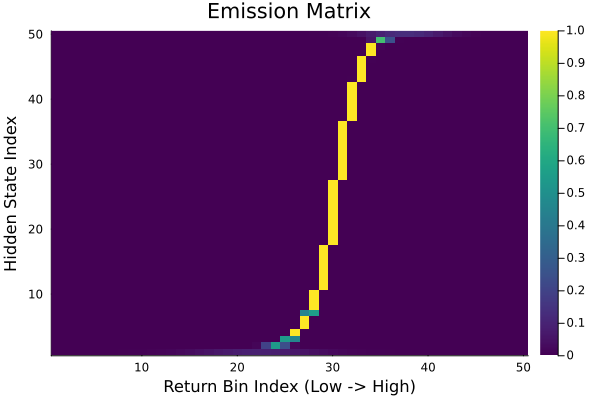

In [85]:
let
    # --- COMPUTE & PLOT LEARNED EMISSION MATRIX ---
    # We discretize the learned Gaussians to visualize them as a matrix
    
    # 1. Define Grid
    min_ret, max_ret = extrema(in_sample_dataset)
    num_bins = number_of_states
    grid_points = range(min_ret, stop=max_ret, length=num_bins)
    step_size = grid_points[2] - grid_points[1]
    
    # 2. Build Matrix (Rows=States, Cols=Return Bins)
    E_estimated = zeros(number_of_states, num_bins)
    for s in 1:number_of_states
        d = model.emission[s]
        for (j, x_val) in enumerate(grid_points)
            # Probability Mass ≈ PDF * StepSize
            E_estimated[s, j] = pdf(d, x_val) * step_size
        end
        # Normalize rows (handle numerical edges)
        row_sum = sum(E_estimated[s, :])
        if row_sum > 0
            E_estimated[s, :] ./= row_sum
        end
    end
    
    # 3. Plot
    heatmap(
        1:num_bins, 
        1:number_of_states, 
        E_estimated,
        title = "Emission Matrix",
        xlabel = "Return Bin Index (Low -> High)",
        ylabel = "Hidden State Index",
        color = :viridis,
        clims = (0, quantile(vec(E_estimated), 0.99))) # Cap at 99th percentile for visibility
end

In [68]:
# Compute the stationary distrubtion 
T_matrix = zeros(number_of_states, number_of_states)
for i in 1:number_of_states
    T_matrix[i, :] = probs(model.transition[i])
end
π_stationary = (T_matrix^1000)[1, :] # Steady state probabilities

50-element Vector{Float64}:
 0.030055711107414146
 0.018636456035500848
 0.021588760286722925
 0.01695633626010743
 0.01698492523163859
 0.0184397837810316
 0.018506265526854287
 0.020743282137118898
 0.021198107083764836
 0.019486761593664373
 0.018640695318761207
 0.018826170199029567
 0.017857698585830657
 ⋮
 0.020585968359400752
 0.019540159824148303
 0.02172154138928744
 0.0207612000859441
 0.018447512569072826
 0.017502471647067218
 0.022181299881215012
 0.015934174566014973
 0.020434118425916734
 0.015522069876126
 0.02505776214280606
 0.02750397438623762

### Visualize an example in-sample return trajectory
`Unhide` the code block to see how we plotted the observed (red) and simulated (blue) excess growth rate values for a randomly selected sample model generated sample path.

`Unhide` the code block below to see how we plotted the observed and simulated excess annual growth rate distribution for the in-sample data.

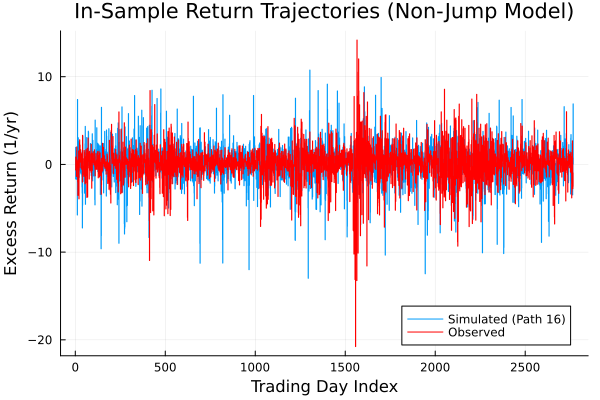

In [69]:
let
    # Select a random path to plot, just like in your working example
    index_to_plot = rand(1:number_of_paths)

    # Plot the SIMULATED data first, creating the plot
    plot(in_sample_decoded_archive[:, index_to_plot], linetype=:steppost, label="Simulated (Path $(index_to_plot))")

    # Add the OBSERVED data to the plot, slicing it to match the simulation length
    plot!(in_sample_dataset[1:(number_of_steps - 1)], linetype=:steppost, c=:red, label="Observed")
    
    # Add labels and a title
    xlabel!("Trading Day Index")
    ylabel!("Excess Return (1/yr)")
    title!("In-Sample Return Trajectories (Non-Jump Model)")
end

### Check: Are the Simulated and observed in-sample distributions the same?
If our Markov model is correct, then the observed excess growth rate distribution and the excess growth distribution calculated by our model should look like they are drawn from the same distribution. To check this hypothesis, use [the ApproximateTwoSampleKSTest exported by the HypothesisTests.jl package](https://github.com/JuliaStats/HypothesisTests.jl) with the hypotheses:
* `H0:null hypothesis` is that `x` and `y` are drawn from the same distribution against the `H1:alternative hypothesis` that `x` and `y` come from different distributions.

Let's run [the ApproximateTwoSampleKSTest function](https://github.com/JuliaStats/HypothesisTests.jl) on a single (randomly selected) example trajectory to see what happens (most of the time, we fail to reject `H0`, i.e., the test suggests `x` and `y` are from the same distribution):

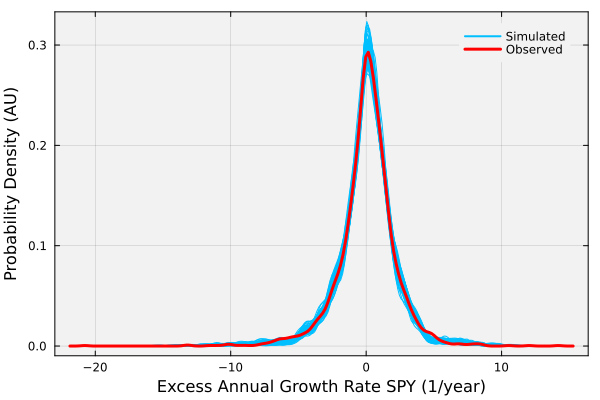

In [70]:
let
    q = plot();
    density!(in_sample_decoded_archive[:,1], lw=2, c=:deepskyblue1, label="Simulated",
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    for i ∈ 2:number_of_paths
        density!(in_sample_decoded_archive[:,i], lw=1, c=:deepskyblue1, label="")
    end
    density!(in_sample_dataset, c=:red, lw=3, label="Observed")
    xlabel!("Excess Annual Growth Rate $(ticker) (1/year)", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)
    current()
end

In [71]:
ApproximateTwoSampleKSTest(in_sample_dataset,in_sample_decoded_archive[:,rand(1:number_of_paths)])

Approximate two sample Kolmogorov-Smirnov test
----------------------------------------------
Population details:
    parameter of interest:   Supremum of CDF differences
    value under h_0:         0.0
    point estimate:          0.0120329

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.9882

Details:
    number of observations:   [2766,2767]
    KS-statistic:              0.4475281250746162


However, we have `number_of_paths` example trajectories (not just one), so let's do the same test on each sample and compute an overall expected score. Specify a `pvalue_cutoff` value to check against. If the test returns `pvalue > pvalue_cutoff,` then we fail to reject `H0:null hypothesis`, i.e., `x` and `y` appear to be drawn from the same distribution.

In [72]:
let
    pvalue_cutoff = 0.05; # cutoff
    pass_counter = 0;
    for i ∈ 1:number_of_paths
        test_value = ApproximateTwoSampleKSTest(in_sample_dataset,in_sample_decoded_archive[:,i]) |> pvalue
        if (test_value > pvalue_cutoff)
            pass_counter += 1 # we pass (fail to reject) x and y are from the same distribution
        end
    end
    println("Pass percentage: $((pass_counter/number_of_paths)*100)%")
end

Pass percentage: 98.0%


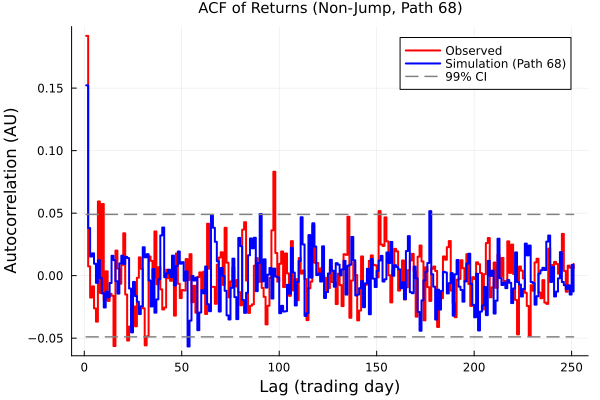

In [73]:
let
    random_index = rand(1:number_of_paths)
    simulated_path = in_sample_decoded_archive[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path, "ACF of Returns (Non-Jump, Path $(random_index))", random_index)
end

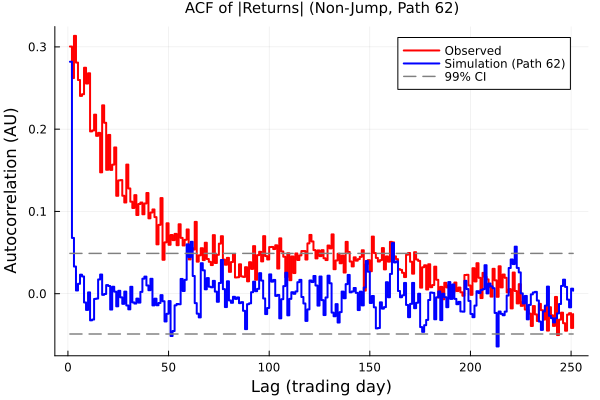

In [74]:
let
    random_index = rand(1:number_of_paths)
    simulated_path = in_sample_decoded_archive[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path, "ACF of |Returns| (Non-Jump, Path $(random_index))", random_index, is_absolute=true)
end

### Conclusion from the Non-Jump Model Analysis

The autocorrelation plots reveal a key insight:
* **Success:** The standard HMM successfully replicates the lack of significant autocorrelation in raw returns, consistent with the efficient market hypothesis.
* **Failure:** The model completely fails to reproduce the strong, persistent autocorrelation in **absolute returns**. This means the simple HMM **cannot capture volatility clustering**, a critical stylized fact of financial markets.

This failure motivates the need for a more sophisticated model, which we explore in Task 4.

## Task 3: Improving the Model with Jumps (Regime Teleportation)

The Standard HMM captures the distribution well but fails to capture **Volatility Clustering** (the fact that large moves follow large moves). This is because the standard transition matrix allows the model to "heal" back to neutral states too quickly.

To fix this, we introduce a **Continuous HMM with Jumps**.
* **Mechanism:** Occasionally, instead of transitioning normally, the model "teleports" to a **Tail State** (Extreme Crash or Boom).
* **Persistence:** Once in a jump event, it stays there for a random duration governed by a Poisson distribution. This forces the model to cluster volatility.

We define:
* $\epsilon$: Probability of a jump event starting.
* $\lambda$: Mean duration of the jump event.

Let us first estimate `λ::Int64` from empirical data

Then, let us estimate `ϵ::Float64` from empirical data

In [75]:
# --- GRID SEARCH WITH FIXED SEED ---

# 1. LOCK THE RANDOMNESS 
# This ensures you get the exact same "random" paths every time you run this cell.
Random.seed!(33) 

# 2. Targets
target_data = in_sample_dataset
target_acf = autocor(abs.(target_data), 1:252)
target_kurtosis = kurtosis(target_data)

# 3. Configuration
run_grid_search = true
# Use a slightly coarser grid if it's too slow, or keep your fine grid
epsilon_grid = 0.0001:0.0001:0.001 
lambda_grid = 1.0:2.0:60.0       

if run_grid_search
    println("Starting Grid Search...")
    
    best_error = Inf
    best_params = (ϵ=0.0, λ=0.0)
    
    n_search_paths = 100 

    for ϵ_val in epsilon_grid
        for λ_val in lambda_grid
            
            # --- A. BUILD ---
            temp_model = build(MyContinuousHiddenMarkovModelWithJumps, (
                base_model = model, 
                epsilon = ϵ_val, 
                lambda = λ_val
            ))

            # --- B. SIMULATE ---
            sim_states = simulate_jumps_stationary(temp_model, number_of_steps, n_search_paths, π_stationary)
            
            # --- C. COMPUTE METRICS ---
            avg_sim_acf = zeros(length(target_acf))
            avg_sim_kurt = 0.0
            
            for i in 1:n_search_paths
                # Decode
                path_returns = [rand(temp_model.emission[s]) for s in sim_states[:, i]]
                
                # Accumulate
                avg_sim_acf .+= autocor(abs.(path_returns), 1:252)
                avg_sim_kurt += kurtosis(path_returns)
            end
            
            # Average
            avg_sim_acf ./= n_search_paths
            avg_sim_kurt /= n_search_paths
            
            # --- D. LOSS ---
            acf_error = sum((avg_sim_acf .- target_acf).^2)
            kurt_error = (avg_sim_kurt - target_kurtosis)^2
            
            # Weighted Loss
            total_error = acf_error + (0.2 * kurt_error)

            if total_error < best_error
                best_error = total_error
                best_params = (ϵ=ϵ_val, λ=λ_val)
            end
        end
    end
    
    # Export final params to global variables
    global final_epsilon = best_params.ϵ
    global final_lambda = best_params.λ
    println("Optimal parameters found (Fixed Seed): ϵ=$final_epsilon, λ=$final_lambda")

else
    global final_epsilon = 0.0005
    global final_lambda = 51.0
    println("Skipping search. Using manual parameters: ϵ=$final_epsilon, λ=$final_lambda")
end

Starting Grid Search...
Optimal parameters found (Fixed Seed): ϵ=0.0004, λ=43.0


In [76]:
# --- BUILD JUMP MODEL ---

#  Wrap the existing Continuous Model
jump_model = build(MyContinuousHiddenMarkovModelWithJumps, (
    base_model = model,  # The model we trained in Task 1/2
    epsilon = final_epsilon,
    lambda = final_lambda
));

In [77]:
# --- SIMULATION (WITH JUMPS) ---

# 1. Run Simulation to get States (Integers)
# Use a consistent name for the encoded (state) archive
encoded_archive_jumps = simulate_jumps_stationary(jump_model, number_of_steps, n_search_paths, π_stationary);

# 2. Decode States into Returns (Floats)
# Initialize the array to hold the returns
decoded_archive_jumps = Array{Float64, 2}(undef, number_of_steps, number_of_paths);

# Loop to fill the array
for i ∈ 1:number_of_paths
    for j ∈ 1:number_of_steps
        # READ from the encoded states
        s = encoded_archive_jumps[j,i];
        
        # Get the distribution
        d = jump_model.emission[s]
        
        # WRITE to the decoded returns
        decoded_archive_jumps[j,i] = rand(d)
    end
end

### Visualize an example in-sample jump return trajectory
`Unhide` the code block to see how we plotted the observed (red) and simulated (blue) excess growth rate values for a randomly selected sample model generated sample path.

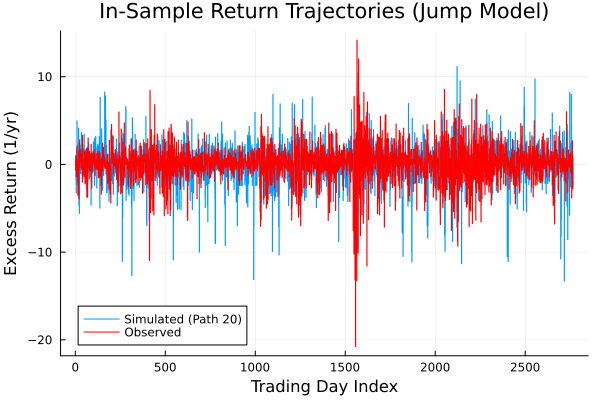

In [78]:
let
    # Select a random path to plot, just like in your working example
    index_to_plot = 20 #rand(1:number_of_paths)

    # Plot the SIMULATED data first, creating the plot
    plot(decoded_archive_jumps[:,index_to_plot], linetype=:steppost, label="Simulated (Path $(index_to_plot))")

    # Add the OBSERVED data to the plot, slicing it to match the simulation length
    plot!(in_sample_dataset[1:(number_of_steps - 1)], linetype=:steppost, c=:red, label="Observed")
    
    # Add labels and a title
    xlabel!("Trading Day Index")
    ylabel!("Excess Return (1/yr)")
    title!("In-Sample Return Trajectories (Jump Model)")
end

### Check: Are the predicted jump model returns and observed in-sample distributions the same?
If our jump Markov model is correct, then the observed excess growth rate distribution and the excess growth distribution calculated by our jump model should look like they are drawn from the same distribution. To check this hypothesis, use [the ApproximateTwoSampleKSTest exported by the HypothesisTests.jl package](https://github.com/JuliaStats/HypothesisTests.jl) with the hypotheses:
* `H0:null hypothesis` is that `x` and `y` are drawn from the same distribution against the `H1:alternative hypothesis` that `x` and `y` come from different distributions.

Let's run [the ApproximateTwoSampleKSTest function](https://github.com/JuliaStats/HypothesisTests.jl) on a single (randomly selected) example trajectory to see what happens (most of the time, we fail to reject `H0`, i.e., the test suggests `x` and `y` are from the same distribution):

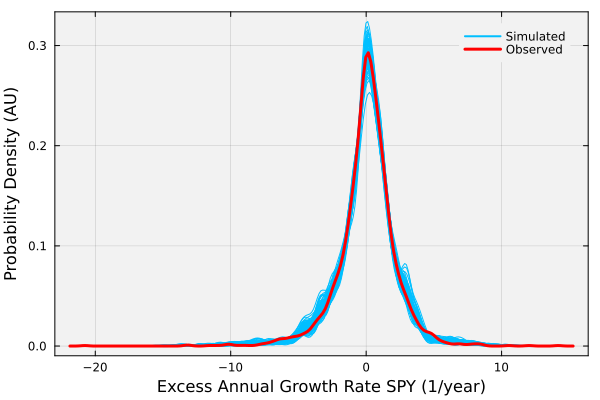

In [79]:
let
    q = plot();
    density!(decoded_archive_jumps[:,1], lw=2, c=:deepskyblue1, label="Simulated",
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    for i ∈ 2:number_of_paths
        density!(decoded_archive_jumps[:,i], lw=1, c=:deepskyblue1, label="")
    end
    density!(in_sample_dataset, c=:red, lw=3, label="Observed")
    xlabel!("Excess Annual Growth Rate $(ticker) (1/year)", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)
    current()

    # # Save the figure
    # savefig(joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-ExcessGrowthRate-Probability-Density-HMM.svg"));

end


In [80]:
let
    pvalue_cutoff = 0.05; # 95% cutoff
    pass_counter = 0;
    for i ∈ 1:number_of_paths
        test_value = ApproximateTwoSampleKSTest(in_sample_dataset,decoded_archive_jumps[:,i]) |> pvalue
        if (test_value > pvalue_cutoff)
            pass_counter += 1 # we pass (fail to reject) x and y are from the same distribution
        end
    end
    println("Pass percentage: $((pass_counter/number_of_paths)*100)%")
end

Pass percentage: 87.0%


### Stylized facts for in-sample dataset
This task compares the stylized facts for the observed insample and simulated excess growth datasets. In particular, we'll look at two stylized facts, namely, the autocorrelation of the excess growth rate and the volatility clustering, i.e., the autocorrelation of the absolute value of the excess growth rate.

#### Lack of Autocorrelation of Returns

First, we test a key stylized fact derived from the [random walk hypothesis](https://en.wikipedia.org/wiki/Random_walk_hypothesis): the autocorrelation of raw returns should be statistically insignificant for all lags. A model that successfully captures market behavior should be able to reproduce this lack of linear predictability.

##### Summary of Findings
* The plot below compares the autocorrelation of the observed **in-sample** returns (`Rᵢ`) with a randomly selected simulation path.
* As expected, both the real-world data (red) and the simulated data (blue) show near-zero autocorrelation that lies mostly within the 95% confidence interval.
* This confirms that our model successfully captures this feature of the data.

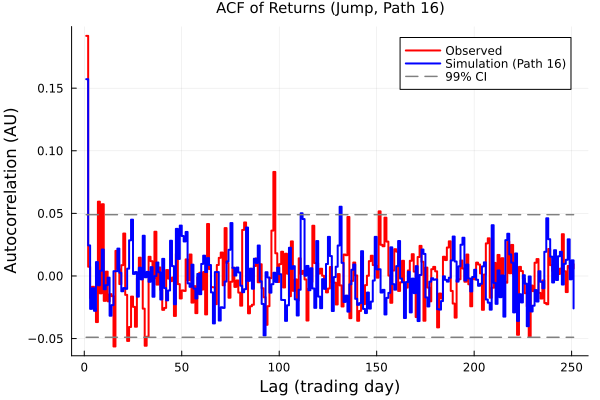

In [81]:
let
    random_index = rand(1:number_of_paths)
    simulated_path_jumps = decoded_archive_jumps[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path_jumps, "ACF of Returns (Jump, Path $(random_index))", random_index)
end

#### Volatility Clustering

Next, we examine a more complex stylized fact: **volatility clustering**. This is the tendency for large market movements (of either sign) to be followed by more large movements, and for calm periods to be followed by more calm periods. We test for this by analyzing the autocorrelation of the **absolute value** of the returns.

##### Summary of Findings
* The observed **in-sample** data (red line) shows positive and persistent autocorrelation in its absolute returns. This is the classic signature of volatility clustering.
* The plot below shows that the **Jump Markov model** (blue line) successfully replicates this pattern, demonstrating a significant improvement over a simple HMM. This confirms the jump component is crucial for capturing this key market dynamic.

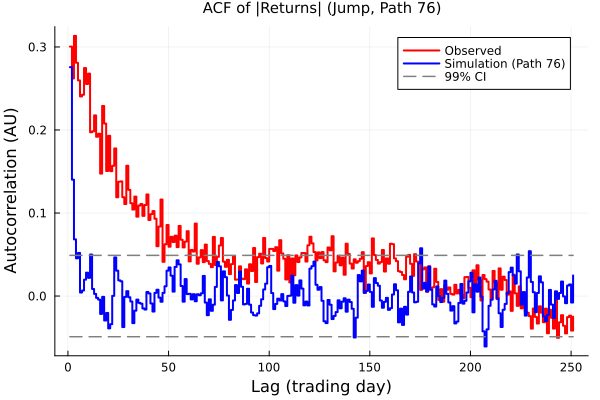

In [82]:
let
    random_index = rand(1:number_of_paths)
    simulated_path_jumps = decoded_archive_jumps[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path_jumps, "ACF of |Returns| (Jump, Path $(random_index))", random_index, is_absolute=true)
end

## Task 4: Save the Model Artifacts
We'll use the hidden Markov Model (HMM) we developed here. Let's save the model to disk to save some time later on. Use the [save(...) method exported by the JLD2.jl package](https://github.com/JuliaIO/JLD2.jl.git) to write a [model file in HDF5 binary format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format). First, we specify a `path` in the `path_to_save_file` variable:

In [83]:
path_to_save_file = joinpath(_PATH_TO_DATA,"HMM-WJ-$(ticker)-daily-aggregate.jld2");

Then we write an [`HDF5 binary file`](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) holding our data to the location specified by `path_to_save_file.` We use the [save(...) function exported by the JLD2.jl package to write a binary save file](https://github.com/JuliaIO/JLD2.jl.git) (later we'll use to the `load(...)` function to reload this data):

In [84]:
# save(path_to_save_file, Dict("model"=>model, "jump_model" => jump_model,
#         "decode"=>decode_distribution_model, "stationary"=>π̄,
#         "insampledataset"=>in_sample_dataset, "encoded_archive" => encoded_archive, "encoded_archive_with_jumps" => encoded_archive_with_jumps,
#         "in_sample_decoded_archive_with_jumps" => in_sample_decoded_archive_with_jumps,
#         "in_sample_decoded_archive" => in_sample_decoded_archive));

## Overall Conclusion

This analysis successfully demonstrated both the capabilities and the limitations of Hidden Markov Models for modeling financial returns.

The key findings are:
1.  **Data Characterization:** The underlying distribution of daily excess returns is characterized by "fat tails," which are better modeled by a **Student's t-distribution** than a Laplace or Normal distribution.

2.  **Standard HMM Performance:** A standard HMM is effective at capturing the basic return distribution and the lack of autocorrelation in raw returns. However, it **fundamentally fails** to reproduce the volatility clustering observed in the market.

3.  **Jump Model Superiority:** By introducing a mechanism for jumps, the modified HMM is able to successfully replicate volatility clustering. This confirms that **the HMM with jumps is a demonstrably superior model** for capturing the essential stylized facts of financial returns.

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. You should decide solely based on your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.